# Εργασία Εξαμήνου - Μέρος B
## Κατηγοριοποίηση, Fusion και Αξιολόγηση

**Ονόματα & ΑΜ:**
- Γιώργος Δέλγας , 1115202200036
- Γιώργος Παλαιοκώστας , 1115202200126

In [153]:
%pip install wordcloud nltk vaderSentiment matplotlib scikit-learn pandas numpy --quiet    

Note: you may need to restart the kernel to use updated packages.


In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tarfile
import bz2
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, silhouette_score, classification_report
)

from gensim.models import Word2Vec

import warnings
warnings.filterwarnings('ignore')

# Για ομοιόμορφα γραφήματα
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Ορισμός του random seed για αναπαραγωγιμότητα
SEED = 42

print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
## 0. Συλλογή Δεδομένων (Data Collection)

Οπως και στο Part A

Φορτώνουμε τα 5 αρχεία του dataset και τα συνδέουμε μέσω του κοινού πεδίου `id` (Song ID).  
Στόχος είναι να κρατήσουμε μόνο τα τραγούδια που έχουν δεδομένα και στις 3 κύριες πηγές: **Genre, Audio (MFCC), Lyrics**.

### 0.1 Φόρτωση Genres - Εύρεση Top-5

Κάθε τραγούδι μπορεί να ανήκει σε περισσότερα από ένα genres (comma-separated).  
Κρατάμε τη λίστα των genres αφαιρόντας duplicates , βρίσκουμε τα 5 πιο συχνά και φιλτράρουμε το dataset.

In [155]:
df_genres = pd.read_csv('id_genres.csv', sep='\t')
print(f'Γραμμές: {len(df_genres)}')
df_genres.head()

Γραμμές: 109269


,id,genres
0,0009fFIM1eYThaPg,pop
1,0010xmHR6UICBOYT,underground hip hop
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave"


In [156]:
# Κρατάμε όλα τα genres ανά τραγούδι, χωρίς duplicates
df_genres['genre_list_unique'] = df_genres['genres'].str.split(',').apply(
    lambda x: list(dict.fromkeys(g.strip() for g in x))
)

# Flat λίστα genres για να βρούμε τα Top-5
all_genres_flat = df_genres.explode('genre_list_unique')['genre_list_unique']
top5_genres = all_genres_flat.value_counts().head(5).index.tolist()
print('Top-5 Genres:', top5_genres)

# Φιλτράρισμα σε song-level dataframe: κρατάμε τα τραγούδια που έχουν τουλάχιστον ένα Top-5 genre
df_genres_filtered = df_genres[['id', 'genre_list_unique']].copy()
df_genres_filtered = df_genres_filtered[df_genres_filtered['genre_list_unique'].apply(
    lambda genres: any(genre in top5_genres for genre in genres)
)].copy()

# Exploded view μόνο για genre counts / EDA όταν χρειάζεται
df_genres_exploded = df_genres_filtered.explode('genre_list_unique').copy()
df_genres_exploded.rename(columns={'genre_list_unique': 'genre'}, inplace=True)

print(f"Τραγούδια στα Top-5 Genres: {df_genres_filtered['id'].count()}")
print(f'Γραμμές στο exploded id-genre table: {len(df_genres_exploded)}')

Top-5 Genres: ['rock', 'pop', 'electronic', 'alternative rock', 'indie rock']
Τραγούδια στα Top-5 Genres: 56100
Γραμμές στο exploded id-genre table: 134266


### 0.2 Φόρτωση Audio Features (MFCC Stats)

Το αρχείο είναι TSV συμπιεσμένο με bz2. Περιέχει 13 MFCC μέσους όρους και τον πίνακα συνδιακύμανσης (flattened upper triangle), συνολικά ~104 features ανά τραγούδι.  
Φιλτράρουμε μόνο τα IDs που μας ενδιαφέρουν για εξοικονόμηση μνήμης.

In [157]:
target_ids = set(df_genres_filtered['id'])

chunks = []
with bz2.open('id_mfcc_stats.tsv.bz2', 'rt') as f:
    for chunk in pd.read_csv(f, sep='\t', chunksize=1000):
        filtered = chunk[chunk['id'].isin(target_ids)]
        if not filtered.empty:
            chunks.append(filtered)

df_mfcc = pd.concat(chunks, ignore_index=True)
print(f'MFCC rows: {len(df_mfcc)}, columns: {len(df_mfcc.columns)}')
df_mfcc.head(2)

MFCC rows: 56100, columns: 105


,id,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,MFCC008,...,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12
0,9EPCgcAlXdgiFsx4,20.640961,-5.828413,-6.140859,2.526664,-1.409552,2.681575,-2.989035,6.298501,3.528709,...,154.790424,21.799839,-15.056062,-19.218533,109.895439,26.262901,-4.037570,120.298222,18.571392,84.858156
1,9epP1yOXfLKlkR3S,24.351542,-16.611490,-10.792922,0.983246,-4.003687,-0.180248,-1.510487,-0.663130,2.915891,...,57.688839,20.511395,3.479626,-1.560816,63.036257,26.379835,2.551358,55.188890,18.194372,52.472903


### 0.3 Φόρτωση Tags

Τα tags είναι User-Generated Content - δίνουν την «ανθρώπινη» ερμηνεία κάθε τραγουδιού.

In [158]:
df_tags_raw = pd.read_csv('id_tags.csv', sep='\t')
df_tags = df_tags_raw[df_tags_raw['id'].isin(target_ids)][['id', 'tags']].copy()
print(f'Tags rows: {len(df_tags)}')
df_tags.head()

Tags rows: 56100


,id,tags
0,0009fFIM1eYThaPg,"pop,british,female vocalists,dance,cheryl cole"
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock,american artist"
5,00CH4HJdxQQQbJfu,"indie rock,experimental,indie,chillout,shoegaz..."
6,00DZ3XCAQb2FdCc6,"ambient,mellow,instrumental,easy listening,ele..."
8,00IeldeA9ijZOL0P,"pop,bollywood,one world,disney"


### 0.4 Φόρτωση Lyrics από tar.gz

Το αρχείο `processed_lyrics.tar.gz` περιέχει ~109k αρχεία κειμένου, ένα ανά τραγούδι (όνομα αρχείου = `{id}.txt`).  
Κάνουμε iterate στο tar και διαβάζουμε **μόνο** τα αρχεία που αντιστοιχούν στα IDs μας.

In [159]:
lyrics_dict = {}

with tarfile.open('processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        # Εξαγωγή song ID από το όνομα αρχείου (π.χ. processed_lyrics/ABCD1234.txt)
        filename = os.path.basename(member.name)
        if not filename.endswith('.txt'):
            continue
        song_id = filename.replace('.txt', '')
        if song_id in target_ids:
            f = tar.extractfile(member)
            if f:
                lyrics_dict[song_id] = f.read().decode('utf-8', errors='ignore')

df_lyrics = pd.DataFrame(list(lyrics_dict.items()), columns=['id', 'lyrics'])
print(f'Lyrics rows: {len(df_lyrics)}')
df_lyrics.head(2)

Lyrics rows: 56100


,id,lyrics
0,9jbSytob9XRzwvB6,deep feel heart burn deep insid yearn know com...
1,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...


### 0.5 Merge - Intersection

Κρατάμε μόνο τα τραγούδια που έχουν δεδομένα **και στα τρία**: Genre, Audio, Lyrics.

In [160]:
df_merged = df_genres_filtered \
    .merge(df_mfcc, on='id') \
    .merge(df_lyrics, on='id') \
    .merge(df_tags, on='id', how='left')  # tags προαιρετικά

print(f'Τελικό dataset: {df_merged.shape[0]} τραγούδια, {df_merged.shape[1]} στήλες')
print('Κατανομή genres:')
print(df_genres_exploded['genre'].value_counts().head(10))
df_merged.head(3)

Τελικό dataset: 56100 τραγούδια, 108 στήλες
Κατανομή genres:
genre
rock                 23949
pop                  20267
electronic           11739
alternative rock      7591
indie rock            7353
classic rock          4334
hard rock             2518
singer-songwriter     2268
indie pop             2165
experimental          2008
Name: count, dtype: int64


,id,genre_list_unique,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,...,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12,lyrics,tags
0,0009fFIM1eYThaPg,[pop],23.622419,-14.435319,-7.964634,-4.066164,-0.910089,-0.460288,4.683222,2.938227,...,2.908798,-6.870236,116.923098,21.549632,0.300939,110.923613,24.561615,96.538287,sunni day get nowher hide cloud sky pretend ge...,"pop,british,female vocalists,dance,cheryl cole"
1,002Jyd0vN4HyCpqL,"[hard rock, rock, classic rock]",22.909323,-7.674675,-19.895458,1.233454,-20.380484,-3.534497,-20.514660,-4.578214,...,23.668015,15.582351,95.043195,42.135654,15.282257,120.657505,73.015982,122.500418,goer phone freiburg say willi do quit job hitl...,"hard rock,rock,classic rock,american artist"
2,00CH4HJdxQQQbJfu,"[indie rock, experimental, shoegaze]",23.436211,-7.816750,-12.406812,11.062952,-9.058584,-1.206321,-5.282046,-3.253329,...,-36.455772,-2.586953,80.042622,23.692883,-14.386593,92.754345,20.962145,84.711864,crimin walk room ask live way think could woul...,"indie rock,experimental,indie,chillout,shoegaz..."


### 0.6 Audio Embeddings - PCA

Τα MFCC stats είναι υψηλής διάστασης (~104 features) και θορυβώδη. Εφαρμόζουμε:
1. **Κανονικοποίηση** (StandardScaler) - απαραίτητο πριν PCA
2. **PCA** με 95% διατήρηση variance - μειώνει δραστικά τις διαστάσεις

In [161]:
# Στήλες MFCC (όλες εκτός id, text/tags και λιστών genres)
mfcc_cols = [
    c for c in df_merged.columns
    if c not in ['id', 'lyrics', 'tags', 'genre_list_unique']
]
print(f'MFCC feature columns: {len(mfcc_cols)}')

X_audio = df_merged[mfcc_cols].values.astype(float)

# Κανονικοποίηση
scaler = StandardScaler()
X_audio_scaled = scaler.fit_transform(X_audio)

# PCA - κράτα 95% variance
pca = PCA(n_components=0.95, random_state=SEED)
X_audio_pca = pca.fit_transform(X_audio_scaled)

print(f'Αρχικές διαστάσεις: {X_audio.shape[1]}')
print(f'Μετά PCA (95% variance): {X_audio_pca.shape[1]}')
print(f'Explained variance ratio (πρώτες 5 components): {pca.explained_variance_ratio_[:5].round(3)}')

MFCC feature columns: 104
Αρχικές διαστάσεις: 104
Μετά PCA (95% variance): 81
Explained variance ratio (πρώτες 5 components): [0.186 0.063 0.039 0.033 0.03 ]


### 0.7 Text Embeddings - Word2Vec

Εκπαιδεύουμε ένα μοντέλο Word2Vec πάνω στο corpus των στίχων.  
Για κάθε τραγούδι, το embedding είναι ο **μέσος όρος** των word vectors όλων των λέξεων του.

In [162]:
# Tokenization - οι στίχοι είναι ήδη προεπεξεργασμένοι (space-separated tokens)
sentences = [lyric.split() for lyric in df_merged['lyrics'].fillna('')]

# Εκπαίδευση Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # διάσταση embedding
    window=5,          # context window
    min_count=3,       # αγνόησε λέξεις που εμφανίζονται < 3 φορές
    workers=1,
    seed=SEED,
    epochs=10
)

print(f'Vocabulary size: {len(w2v_model.wv)}')
print(f'Vector size: {w2v_model.vector_size}')

Vocabulary size: 23803
Vector size: 100


In [163]:
def song_to_vector(tokens, model):
    """Μέσος όρος word vectors για ένα τραγούδι."""
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(model.vector_size)

X_text = np.array([
    song_to_vector(tokens, w2v_model)
    for tokens in sentences
])

print(f'Text embeddings shape: {X_text.shape}')

Text embeddings shape: (56100, 100)


### 0.8 Προετοιμασία Labels για Κατηγοριοποίηση

Σε κάθε τραγούδι αναθέτουμε ένα **πρωτεύον genre**: Φιλτράρουμε τα genre και κρατάμε μόνο τα Top-5 και από αυτά επιλέγουμε το most popular. Αυτό χρειάζεται για να είναι το πρόβλημα single-label όπως απαιτεί το scikit-learn.

In [164]:
top5_set = set(top5_genres)
genre_counts = df_genres_exploded['genre'].value_counts()

def assign_primary_genre(genre_list):
    valid = [genre for genre in genre_list if genre in top5_set]
    if not valid:
        return None
    return max(valid, key=lambda g: genre_counts.get(g, 0))
    

df_merged['primary_genre'] = df_merged['genre_list_unique'].apply(assign_primary_genre).dropna()

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df_merged['primary_genre'])

print('Κλάσεις:', le.classes_)
print('\nΚατανομή primary genre:')
print(df_merged['primary_genre'].value_counts())

Κλάσεις: ['alternative rock' 'electronic' 'indie rock' 'pop' 'rock']

Κατανομή primary genre:
primary_genre
rock                23949
pop                 17391
electronic           9367
indie rock           3657
alternative rock     1736
Name: count, dtype: int64


## 1. Unimodal Classification Models

Εκπαιδεύουμε δύο ξεχωριστούς ταξινομητές:
- **Model A (Text-only):** Random Forest πάνω στα Word2Vec embeddings.
- **Model B (Audio-only):** Random Forest πάνω στα PCA-reduced MFCC features.

Από τα prediction probabilities επιλέγουμε την κλάση με το μεγαλύτερο probability (μία κλάση για κάθε τραγούδι).

Αξιολόγηση: **10-fold Stratified Cross-Validation** για όλα τα μοντέλα.

In [165]:
# Ορισμός CV - ίδιο αντικείμενο για όλα τα μοντέλα ώστε τα splits να είναι ταυτόσημα
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# --- Model A: Text-only (Random Forest) ---
print('Εκπαίδευση Model A (Text - Random Forest)...')
model_a = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

y_proba_a = cross_val_predict(model_a, X_text, y, cv=cv, method='predict_proba', n_jobs=-1)
y_pred_a  = np.argmax(y_proba_a, axis=1)

acc_a  = accuracy_score(y, y_pred_a)
prec_a = precision_score(y, y_pred_a, average='macro', zero_division=0)
rec_a  = recall_score(y, y_pred_a, average='macro', zero_division=0)
f1_a   = f1_score(y, y_pred_a, average='macro', zero_division=0)

print(f'Model A (Text - Random Forest):')
print(f'  Accuracy:          {acc_a:.4f}')
print(f'  Precision (macro): {prec_a:.4f}')
print(f'  Recall (macro):    {rec_a:.4f}')
print(f'  F1-score (macro):  {f1_a:.4f}')

Εκπαίδευση Model A (Text - Random Forest)...
Model A (Text - Random Forest):
  Accuracy:          0.5478
  Precision (macro): 0.5010
  Recall (macro):    0.3302
  F1-score (macro):  0.3311


In [166]:
# --- Model B: Audio-only (Random Forest) ---
print('Εκπαίδευση Model B (Audio - Random Forest)...')
model_b = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

y_proba_b = cross_val_predict(model_b, X_audio_pca, y, cv=cv, method='predict_proba', n_jobs=-1)
y_pred_b  = np.argmax(y_proba_b, axis=1)

acc_b  = accuracy_score(y, y_pred_b)
prec_b = precision_score(y, y_pred_b, average='macro', zero_division=0)
rec_b  = recall_score(y, y_pred_b, average='macro', zero_division=0)
f1_b   = f1_score(y, y_pred_b, average='macro', zero_division=0)

print(f'Model B (Audio - Random Forest):')
print(f'  Accuracy:          {acc_b:.4f}')
print(f'  Precision (macro): {prec_b:.4f}')
print(f'  Recall (macro):    {rec_b:.4f}')
print(f'  F1-score (macro):  {f1_b:.4f}')

Εκπαίδευση Model B (Audio - Random Forest)...
Model B (Audio - Random Forest):
  Accuracy:          0.6238
  Precision (macro): 0.5350
  Recall (macro):    0.3784
  F1-score (macro):  0.3718


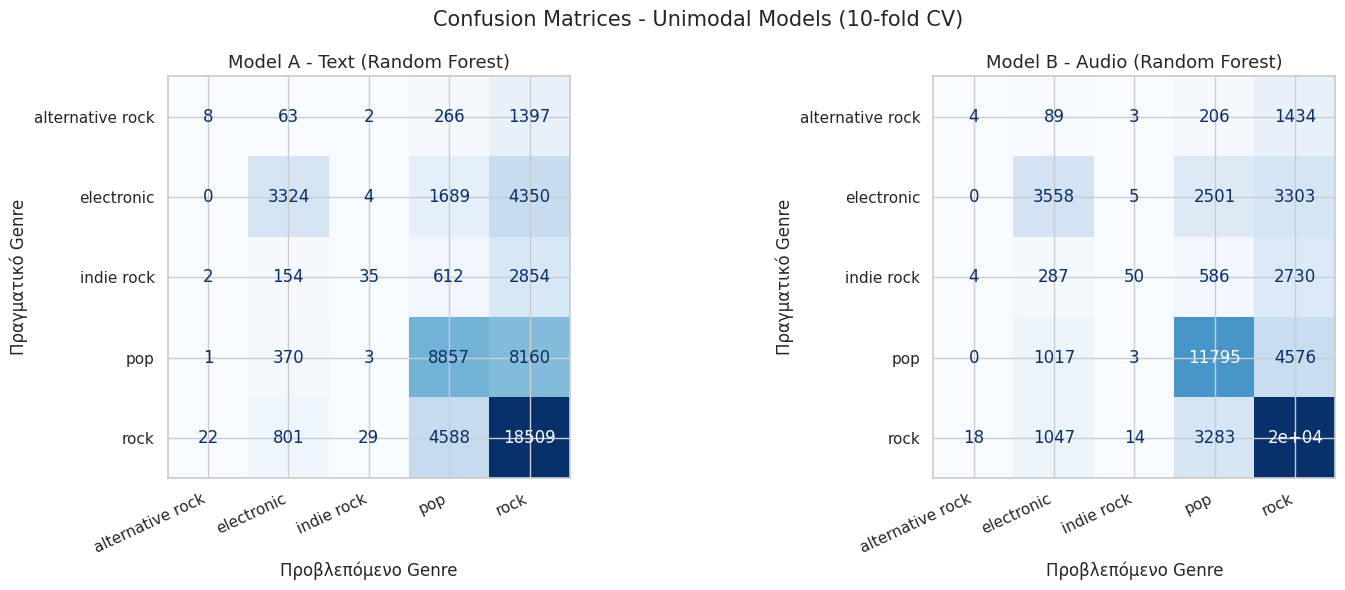

In [167]:
# --- Confusion Matrices: Model A και B ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_a, y_pred_b],
    ['Model A - Text (Random Forest)', 'Model B - Audio (Random Forest)']
):
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Προβλεπόμενο Genre')
    ax.set_ylabel('Πραγματικό Genre')
    for label in ax.get_xticklabels():
        label.set_rotation(25)
        label.set_ha('right')

plt.suptitle('Confusion Matrices - Unimodal Models (10-fold CV)', fontsize=15)
plt.tight_layout()
plt.show()

**Ανάλυση Unimodal αποτελεσμάτων:**

- **Model A (Text):** Χρησιμοποιεί Word2Vec embeddings που αποτυπώνουν ομοιότητα λεξιλογίου. Φαίνεται να αποδίδει καλά σε κατηγορίες όπως το electronic το οποίο είναι λίγο περίεργο μιας και είναι μια αρκετά sound oriented genre (από τον ηλεκτρονικό **ήχο** βγαίνει και το όνομά της). Μπερδεύει μεταξύ τους τις κατηγορίες pop/rock μιας και αυτές παρατηρούμε ότι δεν μπορούν να διαχωριστούν τόσο καλά μέσω των lyrics.
- **Model B (Audio):** Χρησιμοποιεί MFCC features που αποτυπώνουν τον ήχο. Δυσκολεύεται λίγο παραπάνω στο genre του electronic. Ο διαχωρισμός των κατηγοριών pop/rock είναι αρκετά καλύτερος πράγμα που μας δείχνει ότι ο ήχος είναι αρκετά καλό μέσο για να διαχωρίσουμε τις 2 αυτές κατηγορίες.

## 2. Multimodal Fusion (Συνδυασμός)

Υλοποιούμε δύο στρατηγικές συνδυασμού:

- **Early Fusion (Model C):** Ενώνουμε τα audio και text vectors σε ένα διάνυσμα πριν την εκπαίδευση. Το μοντέλο μαθαίνει ταυτόχρονα από τις δύο πηγές.
- **Late Fusion:** Εκπαιδεύουμε ξεχωριστά τα Model A και B και συνδυάζουμε τις προβλέψεις τους με **μέσο όρο** πιθανοτήτων.

In [168]:
# --- Early Fusion: Concatenation ---
X_fused = np.concatenate([X_audio_pca, X_text], axis=1)
print(f'Fused feature space: audio({X_audio_pca.shape[1]}) + text({X_text.shape[1]}) = {X_fused.shape[1]} dims')

print('\nΕκπαίδευση Model C (Early Fusion - Random Forest)...')
model_c = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

y_proba_c = cross_val_predict(model_c, X_fused, y, cv=cv, method='predict_proba', n_jobs=-1)
y_pred_c  = np.argmax(y_proba_c, axis=1)

acc_c  = accuracy_score(y, y_pred_c)
prec_c = precision_score(y, y_pred_c, average='macro', zero_division=0)
rec_c  = recall_score(y, y_pred_c, average='macro', zero_division=0)
f1_c   = f1_score(y, y_pred_c, average='macro', zero_division=0)

print(f'Model C (Early Fusion - Random Forest):')
print(f'  Accuracy:          {acc_c:.4f}')
print(f'  Precision (macro): {prec_c:.4f}')
print(f'  Recall (macro):    {rec_c:.4f}')
print(f'  F1-score (macro):  {f1_c:.4f}')

Fused feature space: audio(81) + text(100) = 181 dims

Εκπαίδευση Model C (Early Fusion - Random Forest)...
Model C (Early Fusion - Random Forest):
  Accuracy:          0.6288
  Precision (macro): 0.5517
  Recall (macro):    0.3797
  F1-score (macro):  0.3745


In [169]:
# --- Late Fusion: Μέσος Όρος Πιθανοτήτων ---
# Τα y_proba_a και y_proba_b παράγονται με τα ίδια CV splits (ίδιο cv αντικείμενο)
# άρα κάθε δείγμα i αξιολογήθηκε στο ίδιο test fold και στα δύο μοντέλα.
y_proba_late = (y_proba_a + y_proba_b) / 2
y_pred_late  = np.argmax(y_proba_late, axis=1)

acc_late  = accuracy_score(y, y_pred_late)
prec_late = precision_score(y, y_pred_late, average='macro', zero_division=0)
rec_late  = recall_score(y, y_pred_late, average='macro', zero_division=0)
f1_late   = f1_score(y, y_pred_late, average='macro', zero_division=0)

print(f'Late Fusion (Average Probabilities):')
print(f'  Accuracy:          {acc_late:.4f}')
print(f'  Precision (macro): {prec_late:.4f}')
print(f'  Recall (macro):    {rec_late:.4f}')
print(f'  F1-score (macro):  {f1_late:.4f}')

Late Fusion (Average Probabilities):
  Accuracy:          0.6410
  Precision (macro): 0.5723
  Recall (macro):    0.3870
  F1-score (macro):  0.3869


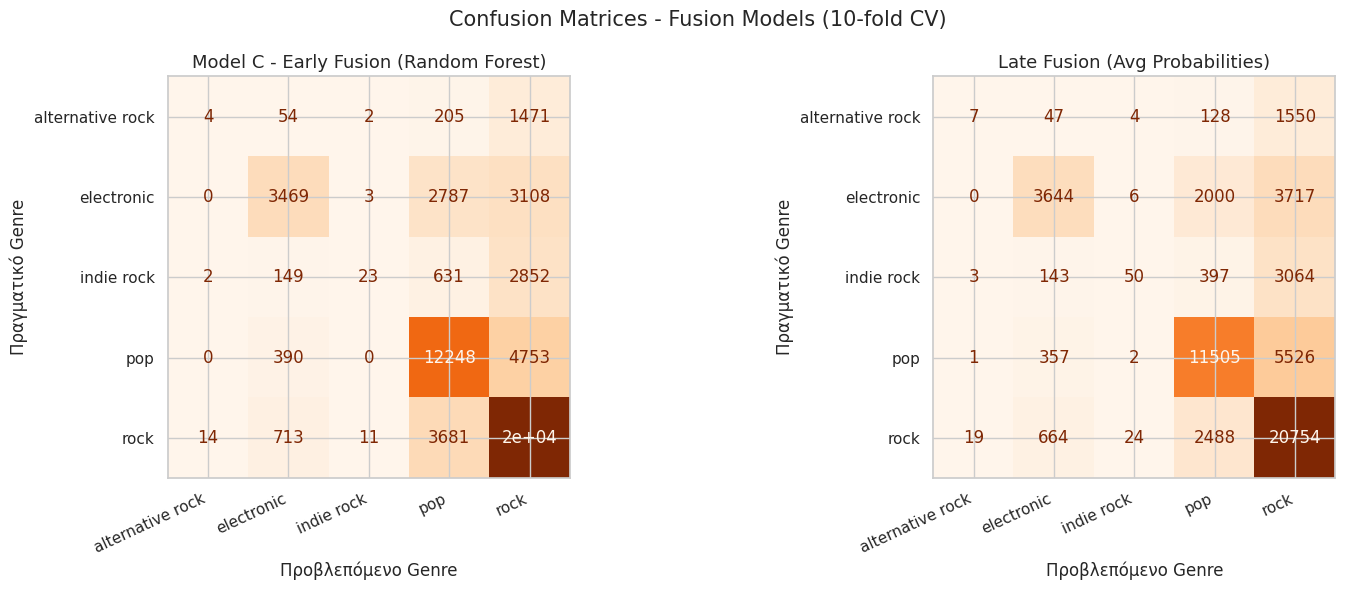

In [170]:
# --- Confusion Matrices: Model C & Late Fusion ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_c, y_pred_late],
    ['Model C - Early Fusion (Random Forest)', 'Late Fusion (Avg Probabilities)']
):
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Προβλεπόμενο Genre')
    ax.set_ylabel('Πραγματικό Genre')
    for label in ax.get_xticklabels():
        label.set_rotation(25)
        label.set_ha('right')

plt.suptitle('Confusion Matrices - Fusion Models (10-fold CV)', fontsize=15)
plt.tight_layout()
plt.show()

**Ανάλυση Fusion αποτελεσμάτων:**

- **Early Fusion (Model C):** Το μοντέλο βλέπει ταυτόχρονα ήχο και κείμενο κατά την εκπαίδευση. Παρατηρούμε αρκετά καλύτερη κατηγοριοποίηση από το Text-Only model ειδικά στον διαχωρισμό rock/pop. Στις άλλες κατηγορίες η βελτίωση είναι μικρότερη αλλά παραμένει θετική.
- **Late Fusion:** Κάθε model μαθαίνει ξεχωριστά και οι αποφάσεις συνδυάζονται. Παρατηρούμε τα καλύτερα αποτελέσματα σε σχέση με όλα τα προηγούμενα μοντέλα σε όλες τις μετρικές.

Παρατηρούμε ότι ο συνδυασμός 2 biased models παράγει καλύτερα αποτελέσματα από ένα non-biased model.

## 3. Σύγκριση & Αξιολόγηση

Σύγκριση όλων των μοντέλων με macro-averaged metrics και ανάλυση ανά genre.

In [171]:
# --- Συγκεντρωτικός Πίνακας Αποτελεσμάτων ---
results = {
    'Model': ['Model A (Text-only)', 'Model B (Audio-only)', 'Model C (Early Fusion)', 'Late Fusion'],
    'Accuracy':          [acc_a, acc_b, acc_c, acc_late],
    'Precision (macro)': [prec_a, prec_b, prec_c, prec_late],
    'Recall (macro)':    [rec_a,  rec_b,  rec_c,  rec_late],
    'F1-score (macro)':  [f1_a,   f1_b,   f1_c,   f1_late],
}
df_results = pd.DataFrame(results).set_index('Model')
print('--- Συγκεντρωτικά Αποτελέσματα (10-fold CV) ---')
print(df_results.round(4).to_string())

--- Συγκεντρωτικά Αποτελέσματα (10-fold CV) ---
                        Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
Model                                                                                
Model A (Text-only)       0.5478             0.5010          0.3302            0.3311
Model B (Audio-only)      0.6238             0.5350          0.3784            0.3718
Model C (Early Fusion)    0.6288             0.5517          0.3797            0.3745
Late Fusion               0.6410             0.5723          0.3870            0.3869


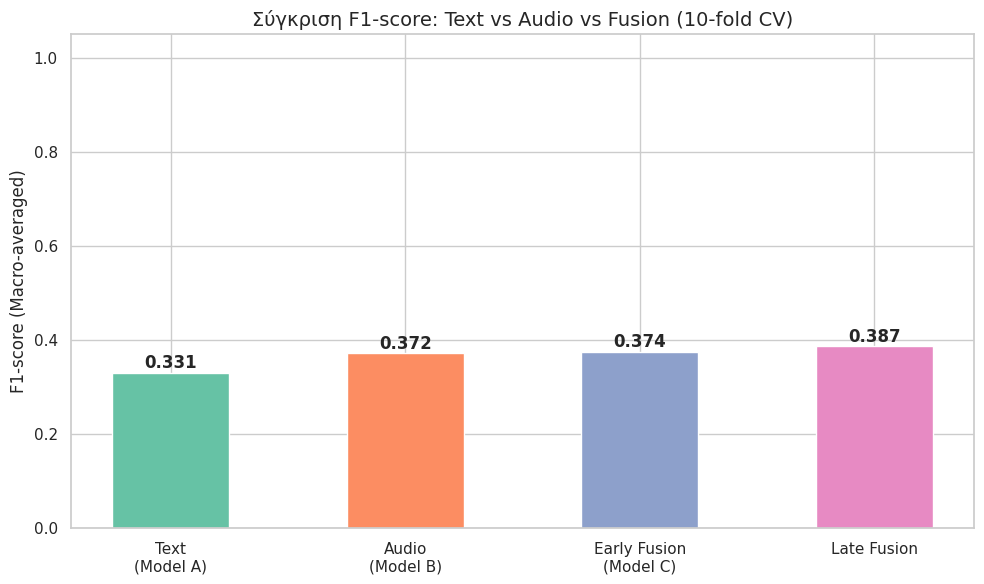

In [172]:
# --- Bar Chart: F1-score Σύγκριση ---
model_labels = ['Text\n(Model A)', 'Audio\n(Model B)', 'Early Fusion\n(Model C)', 'Late Fusion']
f1_values    = [f1_a, f1_b, f1_c, f1_late]
colors = sns.color_palette('Set2', 4)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_labels))
bars = ax.bar(x, f1_values, color=colors, edgecolor='white', width=0.5)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel('F1-score (Macro-averaged)', fontsize=12)
ax.set_title('Σύγκριση F1-score: Text vs Audio vs Fusion (10-fold CV)', fontsize=14)
ax.set_ylim(0, 1.05)

for bar, val in zip(bars, f1_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.show()

F1-score ανά Genre:
                  Text (A)  Audio (B)  Early Fusion (C)  Late Fusion
alternative rock     0.009      0.005             0.005        0.008
electronic           0.472      0.463             0.491        0.512
indie rock           0.019      0.027             0.012        0.027
pop                  0.530      0.660             0.663        0.679
rock                 0.625      0.705             0.702        0.709


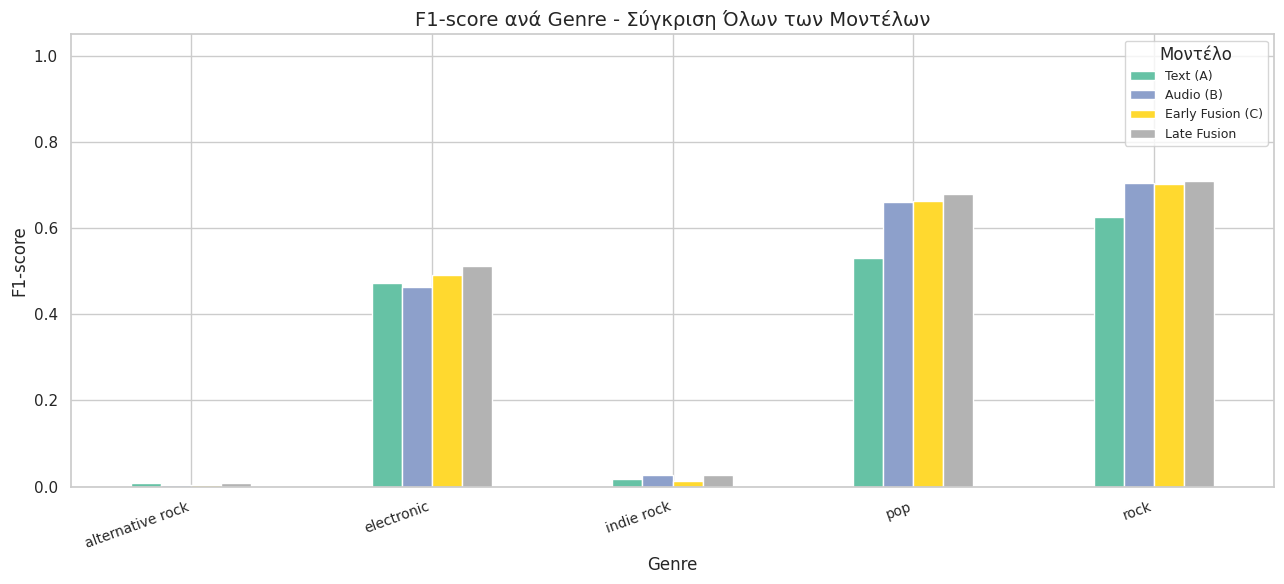

In [173]:
# --- Per-Genre F1-score: Σύγκριση Μοντέλων ---
report_a = classification_report(y, y_pred_a, target_names=le.classes_, output_dict=True, zero_division=0)
report_b = classification_report(y, y_pred_b, target_names=le.classes_, output_dict=True, zero_division=0)
report_c = classification_report(y, y_pred_c, target_names=le.classes_, output_dict=True, zero_division=0)
report_l = classification_report(y, y_pred_late, target_names=le.classes_, output_dict=True, zero_division=0)

genres = list(le.classes_)
df_per_genre = pd.DataFrame({
    'Text (A)':          [report_a[g]['f1-score'] for g in genres],
    'Audio (B)':         [report_b[g]['f1-score'] for g in genres],
    'Early Fusion (C)':  [report_c[g]['f1-score'] for g in genres],
    'Late Fusion':       [report_l[g]['f1-score'] for g in genres],
}, index=genres)

print('F1-score ανά Genre:')
print(df_per_genre.round(3).to_string())

fig, ax = plt.subplots(figsize=(13, 6))
df_per_genre.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('F1-score ανά Genre - Σύγκριση Όλων των Μοντέλων', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('F1-score')
ax.set_xticklabels(genres, rotation=20, ha='right', fontsize=10)
ax.legend(title='Μοντέλο', fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Συγκριτική Ανάλυση:**

**Διαχωρίζονται καλά οι κατηγορίες;**

Αρχικά παρατηρούμε ότι τα indie/alternative rock δεν διαχωρίζονται σχεδόν καθόλου σαν ξεχωριστές κατηγορίες (κατηγοριοποιούνται σαν rock), πράγμα που μας δείχνει ότι οι διαφορές τους είναι πολύ μικρές και δεν αποτυπώνονται ούτε στο λεξιλόγιο των στίχων ούτε στον ήχο. Αντίθετα, τα electronic, pop και rock διαχωρίζεται αρκετά καλά από τις υπόλοιπες κατηγορίες.

**Ποια genres προβλέπονται καλύτερα από το κείμενο;**

Αρκετά περιέργο είναι ότι το electronic αποδίδει καλύτερα στο Text-Only μοντέλο παρά στo Audio-Only, πράγμα που μας δείχνει ότι το λεξιλόγιο των στίχων του electronic είναι αρκετά ξεχωριστό και πιο εύκολo να διαχωριστεί από τα υπόλoιπα genres σe σχέση μe τoν ήχo του.

**Ποια genres προβλέπονται καλύτερα από τον ήχο;**

Το rock και το pop διαχωρίζονται καλύτερα από τον ήχο παρά από το κείμενο, πράγμα που μας δείχνει ότι ο ήχος είναι πιο διακριτός για αυτές τις κατηγορίες σε σχέση με το λεξιλόγιο των στίχων τους.

**Βοήθησε ο συνδυασμός των δεδομένων;**

Παρατηρούμε ότι ο συνδυασμός των δεδομένων από διάφορες πηγές (ήχος και κείμενο) παράγει καλύτερα αποτελέσματα από τη χρήση μόνο μιας πηγής, το οποίο είναι λογικό μιας και έχουμε παραπάνω πληροφορία για κάθε τραγούδι. Το Late Fusion γενικά αποδίδει καλύτερα από το Early Fusion, πιθανώς επειδή επιτρέπει σε κάθε μοντέλο να εξειδικευτεί στην πηγή του χωρίς να επηρεάζεται από την άλλη. Το Early Fusion μπορεί να δυσκολεύεται να μάθει από δύο διαφορετικές πηγές ταυτόχρονα, ειδικά αν αυτές έχουν διαφορετική φύση (ήχος vs κείμενο).

## 4. Clustering (Unsupervised Learning)

Εφαρμόζουμε **K-Means** στο fused feature space. Στόχος είναι να δούμε αν η μη-επιβλεπόμενη ομαδοποίηση βρίσκει clusters που αντιστοιχούν στα πραγματικά genres.

Μετρικές:
- **Silhouette Score:** βρίσκουμε τον βέλτιστο αριθμό clusters $k$
- **Adjusted Rand Index (ARI):** μετράμε πόσο τα clusters συμφωνούν με τα πραγματικά labels

  k= 2  :  Silhouette Score = 0.6083
  k= 3  :  Silhouette Score = 0.4341
  k= 4  :  Silhouette Score = 0.4622
  k= 5  :  Silhouette Score = 0.4330
  k= 6  :  Silhouette Score = 0.4001
  k= 7  :  Silhouette Score = 0.3987
  k= 8  :  Silhouette Score = 0.3659
  k= 9  :  Silhouette Score = 0.3697
  k=10  :  Silhouette Score = 0.3656

Βέλτιστο k (max Silhouette): 2


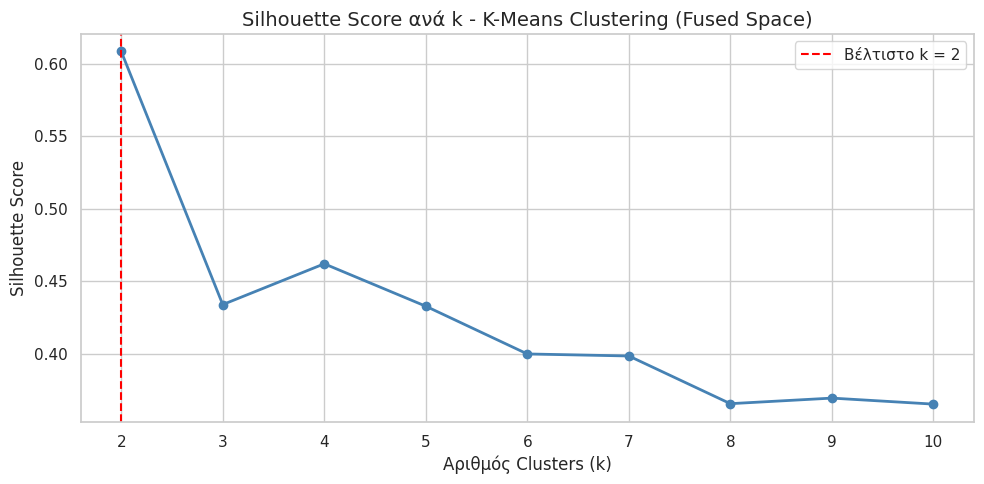

In [174]:
# --- Silhouette Score ανά k ---
# Χρησιμοποιούμε υποσύνολο για ταχύτητα
N_CLUSTER_SAMPLE = min(10000, len(X_fused))
rng = np.random.RandomState(SEED)
idx_sample = rng.choice(len(X_fused), N_CLUSTER_SAMPLE, replace=False)
X_cluster_sample = X_fused[idx_sample]

# Reduce dimensionality με PCA για καλύτερα αποτελέσματα clustering
pca_cluster = PCA(n_components=2, random_state=SEED)
X_cluster_sample = pca_cluster.fit_transform(X_cluster_sample)

K_RANGE = range(2, 11)
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = km.fit_predict(X_cluster_sample)
    sil = silhouette_score(X_cluster_sample, labels_k, sample_size=min(5000, N_CLUSTER_SAMPLE), random_state=SEED)
    silhouette_scores.append(sil)
    print(f'  k={k:2d}  :  Silhouette Score = {sil:.4f}')

best_k = list(K_RANGE)[int(np.argmax(silhouette_scores))]
print(f'\nΒέλτιστο k (max Silhouette): {best_k}')

plt.figure(figsize=(10, 5))
plt.plot(list(K_RANGE), silhouette_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Βέλτιστο k = {best_k}')
plt.xlabel('Αριθμός Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score ανά k - K-Means Clustering (Fused Space)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [175]:
# --- K-Means με βέλτιστο k στο πλήρες dataset ---
km_best = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_labels = km_best.fit_predict(X_fused)

# Adjusted Rand Index
ari = adjusted_rand_score(y, cluster_labels)
print(f'K-Means με k={best_k} (πλήρες dataset: {len(X_fused)} τραγούδια)')
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print('  (0 = τυχαία αντιστοιχία, 1 = τέλεια αντιστοιχία με πραγματικά labels)')

# Κατανομή cluster-genre (cross-tabulation)
df_cluster = pd.DataFrame({
    'cluster': cluster_labels,
    'genre': df_merged['primary_genre'].values
})
ct = pd.crosstab(df_cluster['cluster'], df_cluster['genre'])
print('\nΚατανομή genres ανά cluster:')
print(ct)

K-Means με k=2 (πλήρες dataset: 56100 τραγούδια)
Adjusted Rand Index (ARI): 0.0418
  (0 = τυχαία αντιστοιχία, 1 = τέλεια αντιστοιχία με πραγματικά labels)

Κατανομή genres ανά cluster:
genre    alternative rock  electronic  indie rock    pop   rock
cluster                                                        
0                      56        2216         193   3811    937
1                    1680        7151        3464  13580  23012


t-SNE done.


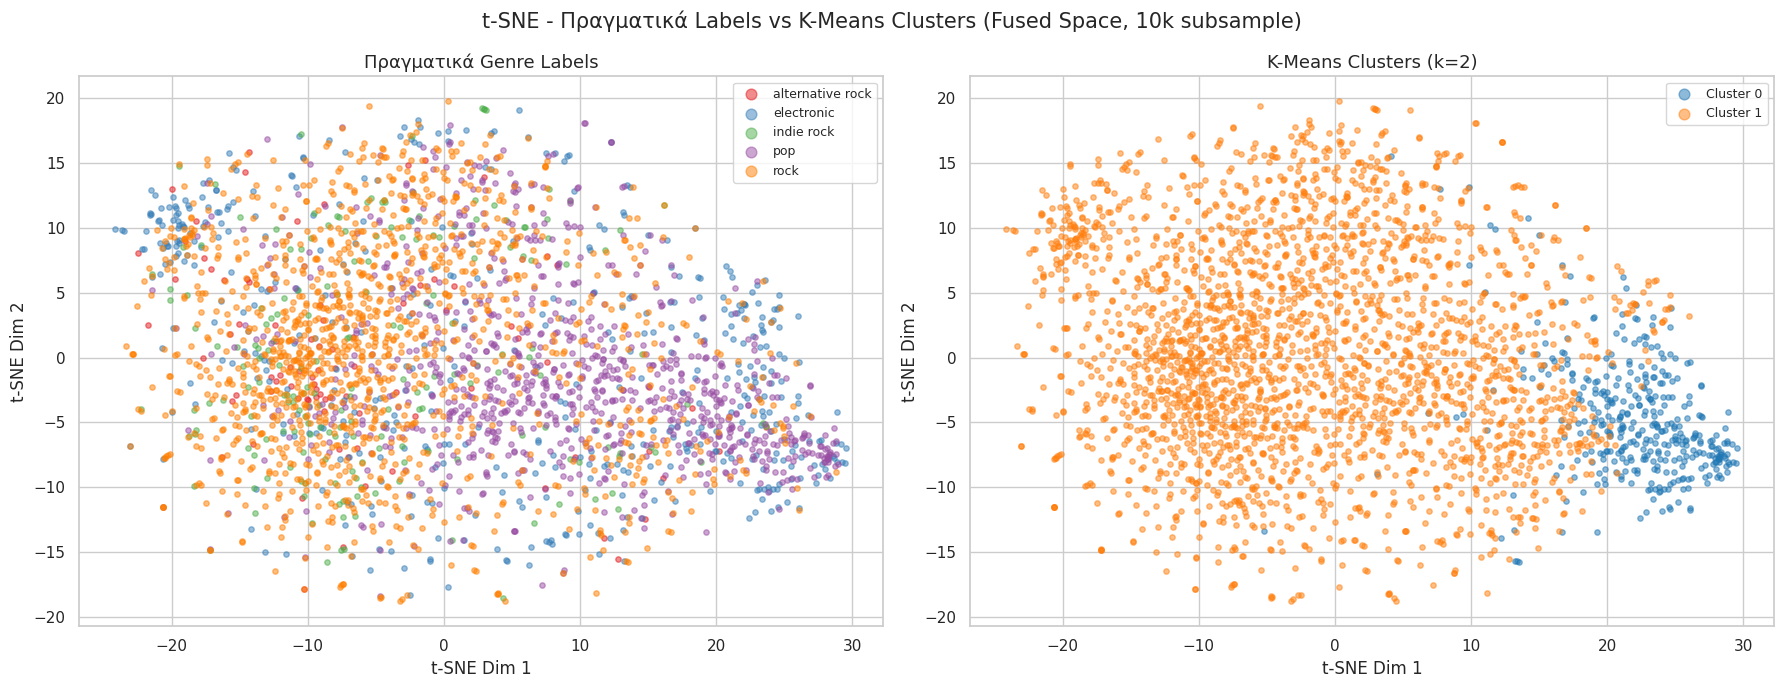

In [176]:
# --- t-SNE Visualization: Πραγματικά Labels vs Clusters ---
N_VIZ = min(3000, len(X_fused))
idx_viz = np.random.RandomState(SEED).choice(len(X_fused), N_VIZ, replace=False)

X_viz        = X_fused[idx_viz]
y_viz        = y[idx_viz]
cluster_viz  = cluster_labels[idx_viz]

tsne_c = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
X_2d   = tsne_c.fit_transform(X_viz)
print('t-SNE done.')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Πραγματικά genre labels
pal_genres = sns.color_palette('Set1', n_colors=len(le.classes_))
for i, genre in enumerate(le.classes_):
    mask = y_viz == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[pal_genres[i]], label=genre, alpha=0.5, s=15)
axes[0].set_title('Πραγματικά Genre Labels', fontsize=13)
axes[0].legend(markerscale=2, fontsize=9)
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')

# K-Means cluster labels
pal_clusters = sns.color_palette('tab10', n_colors=best_k)
for k in range(best_k):
    mask = cluster_viz == k
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[pal_clusters[k]], label=f'Cluster {k}', alpha=0.5, s=15)
axes[1].set_title(f'K-Means Clusters (k={best_k})', fontsize=13)
axes[1].legend(markerscale=2, fontsize=9)
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')

plt.suptitle('t-SNE - Πραγματικά Labels vs K-Means Clusters (Fused Space, 10k subsample)', fontsize=15)
plt.tight_layout()
plt.show()

**Ανάλυση Clustering:**

**Silhouette Score & Βέλτιστο k:**
Το Silhouette Score μας δείχνει ότι ο βέλτιστος αριθμός clusters είναι 2, πολύ λιγότερο από τα 5 genres που έχουμε. Αυτό συμβαίνει επειδή τα genres δεν έχουν ξεκαθάρους ορισμούς. Αυτό που καταλήγει να κάνει ο K-Means είναι να χωρίζει τα τραγούδια σε rock και non-rock, με τα υπόλοιπα genres να βρίσκονται ενδιάμεσα χωρίς να μην σχηματίζουν ξεκάθαρα clusters.

**Adjusted Rand Index (ARI):**
Το ARI μετρά αν τα clusters συμφωνούν με τα πραγματικά labels. Το ARI είναι σχεδόν μηδέν, που δείχνει ότι το K-Means δεν βρίσκει αυτόματα τα ίδια groups. Αυτό είναι αναμενόμενο γιατί:

- **Primary genre**: Κάθε τραγούδι έχει ένα πρωτεύον genre που μπορεί να μην αντιπροσωπεύει πλήρως την πολυπλοκότητα του ήχου/στίχων του.
- **Πολλαπλά genres ανά τραγούδι**: Ένα τραγούδι rock/pop βρίσκεται ενδιάμεσα σε πολλά clusters.
- **Στόχος K-Means**: Ελαχιστοποιεί variance μέσα στα clusters, όχι την καθαρότητα genre.

**Συμπέρασμα:** Το clustering βρίσκει φυσική δομή στα δεδομένα που σχετίζεται αλλά δεν ταυτίζεται με τα genre labels. Αυτό δείχνει ότι τα genres βρίσκονται σε ένα spectrum και δεν αντιστοιχούν σε ξεκάθαρο ήχο/lyrics.